<a href="https://colab.research.google.com/github/Aghil-hub/spotify-barcelona-brand-impact/blob/main/MA_spotify_barca_event_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify–Barcelona Event Study

This notebook evaluates whether Spotify’s March 15, 2022 Barcelona deal announcement generated abnormal stock returns around the event date.

Methodology:

We use the Market Model to estimate normal/expected returns.
Estimation Window: [-250, -20] relative to the event (231 trading days).
Event Window: [-5, +5] around the announcement (11 trading days).
Abnormal Return (AR) = Actual Return - Expected Return
Cumulative Abnormal Return (CAR) = Sum of ARs over the event window.
This analysis quantifies whether the Barcelona deal was perceived as value-creating for Spotify shareholders in the short term.

## 1. Setup

Import the libraries used for data preparation, regression modeling, statistical testing, and visualization.

In [1]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import t

## 2. Load the data

Load the market return dataset and the Spotify stock return dataset.


In [2]:
df_mr = pd.read_excel('Market return data.xlsx')
df_sp = pd.read_excel('Spotify stock price data.xlsx')

In [3]:
df_mr.head()

,Date of Observation,Value-Weighted Return-incl. dividends,Return on the S&P 500 Index
0,2021-03-01,0.024765,0.023791
1,2021-03-02,-0.009017,-0.008081
2,2021-03-03,-0.014661,-0.013066
3,2021-03-04,-0.016690,-0.013417
4,2021-03-05,0.017372,0.019496


In [4]:
df_mr.shape

(276, 3)

In [5]:
df_sp.head()

,PERMNO,Names Date,Ticker Symbol,Price or Bid/Ask Average,Volume,Returns
0,17782,2021-03-01,SPOT,321.279999,1541982,0.045221
1,17782,2021-03-02,SPOT,322.739990,1482998,0.004544
2,17782,2021-03-03,SPOT,300.239990,1636578,-0.069716
3,17782,2021-03-04,SPOT,285.010010,2591395,-0.050726
4,17782,2021-03-05,SPOT,274.980011,2599418,-0.035192


In [6]:
df_sp.shape

(276, 6)

## 3. Clean and prepare data

Rename key columns, merge both datasets on `Date`, and keep only the variables needed for the event study.

In [7]:
# Rename columns
df_sp.rename(columns={'Names Date': 'Date'}, inplace=True)
df_mr.rename(columns={'Date of Observation': 'Date'}, inplace=True)

In [8]:
# Merge market return with spotify stock returns on 'Date'
df = pd.merge(df_mr, df_sp, on='Date')

In [9]:
df.head()

,Date,Value-Weighted Return-incl. dividends,Return on the S&P 500 Index,PERMNO,Ticker Symbol,Price or Bid/Ask Average,Volume,Returns
0,2021-03-01,0.024765,0.023791,17782,SPOT,321.279999,1541982,0.045221
1,2021-03-02,-0.009017,-0.008081,17782,SPOT,322.739990,1482998,0.004544
2,2021-03-03,-0.014661,-0.013066,17782,SPOT,300.239990,1636578,-0.069716
3,2021-03-04,-0.016690,-0.013417,17782,SPOT,285.010010,2591395,-0.050726
4,2021-03-05,0.017372,0.019496,17782,SPOT,274.980011,2599418,-0.035192


In [10]:
df.shape

(276, 8)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Data columns (total 8 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Date                                   276 non-null    datetime64[ns]
 1   Value-Weighted Return-incl. dividends  276 non-null    float64       
 2   Return on the S&P 500 Index            276 non-null    float64       
 3   PERMNO                                 276 non-null    int64         
 4   Ticker Symbol                          276 non-null    object        
 5   Price or Bid/Ask Average               276 non-null    float64       
 6   Volume                                 276 non-null    int64         
 7   Returns                                276 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 17.4+ KB


In [12]:
# Drop columns which are not required
drop = ['PERMNO','Ticker Symbol','Price or Bid/Ask Average','Volume']
df.drop(drop, axis=1, inplace=True)

In [13]:
# Rename return columns
df.rename(columns={'Value-Weighted Return-incl. dividends': 'value_weighted_ret'}, inplace=True)
df.rename(columns={'Returns': 'spotify_return'}, inplace=True)
df.rename(columns={'Return on the S&P 500 Index':'sp_ret'}, inplace = True)

In [14]:
df.head()

,Date,value_weighted_ret,sp_ret,spotify_return
0,2021-03-01,0.024765,0.023791,0.045221
1,2021-03-02,-0.009017,-0.008081,0.004544
2,2021-03-03,-0.014661,-0.013066,-0.069716
3,2021-03-04,-0.016690,-0.013417,-0.050726
4,2021-03-05,0.017372,0.019496,-0.035192


In [15]:
# Sort by 'Date'
df.sort_values('Date', inplace=True)

In [16]:
df.head()

,Date,value_weighted_ret,sp_ret,spotify_return
0,2021-03-01,0.024765,0.023791,0.045221
1,2021-03-02,-0.009017,-0.008081,0.004544
2,2021-03-03,-0.014661,-0.013066,-0.069716
3,2021-03-04,-0.016690,-0.013417,-0.050726
4,2021-03-05,0.017372,0.019496,-0.035192


## 4. Define the event and windows

Set **March 15, 2022** as the event date.

Create an estimation window of `[-250, -20]` and an event window of `[-5, +5]`.

In [17]:
# Set event date as 2022-03-15
df['Date'] = pd.to_datetime(df['Date'])
event_date_ref = pd.to_datetime('2022-03-15')
df['event_date'] = (df['Date'] == event_date_ref).astype(int)

In [18]:
df[df['event_date'] == 1]

,Date,value_weighted_ret,sp_ret,spotify_return,event_date
263,2022-03-15,0.019118,0.021408,0.036578,1


In [19]:
# Set estimation window
event_date_index = df[df['Date'] == event_date_ref].index[0]

estimation_start_idx = event_date_index - 250
estimation_end_idx = event_date_index - 20

df['Estimation_window'] = 0
df.loc[estimation_start_idx:estimation_end_idx, 'Estimation_window'] = 1

In [20]:
# Set event window
event_window_start_idx = event_date_index - 5
event_window_end_idx = event_date_index + 5

df['event_window'] = 0
df.loc[event_window_start_idx:event_window_end_idx, 'event_window'] = 1

In [21]:
df[df['Estimation_window'] == 1]

,Date,value_weighted_ret,sp_ret,spotify_return,event_date,Estimation_window,event_window
13,2021-03-18,-0.017954,-0.014761,-0.041009,0,1,0
14,2021-03-19,0.001804,-0.000603,0.001398,0,1,0
15,2021-03-22,0.004791,0.007025,0.012348,0,1,0
16,2021-03-23,-0.011993,-0.007631,-0.029658,0,1,0
17,2021-03-24,-0.009090,-0.005467,-0.032248,0,1,0
...,...,...,...,...,...,...,...
239,2022-02-08,0.009147,0.008401,-0.032593,0,1,0
240,2022-02-09,0.016251,0.014517,0.057678,0,1,0
241,2022-02-10,-0.016293,-0.018116,-0.043649,0,1,0
242,2022-02-11,-0.017672,-0.018969,-0.035155,0,1,0


In [22]:
df[df['Estimation_window'] == 1].describe()

,Date,value_weighted_ret,sp_ret,spotify_return,event_date,Estimation_window,event_window
count,231,231.000000,231.000000,231.000000,231.0,231.0,231.0
mean,2021-08-31 02:35:50.649350656,0.000292,0.000478,-0.001928,0.0,1.0,0.0
min,2021-03-18 00:00:00,-0.023331,-0.024391,-0.167570,0.0,1.0,0.0
25%,2021-06-09 12:00:00,-0.004303,-0.003771,-0.018201,0.0,1.0,0.0
50%,2021-08-31 00:00:00,0.000553,0.001165,-0.001679,0.0,1.0,0.0
75%,2021-11-20 12:00:00,0.005496,0.005526,0.014899,0.0,1.0,0.0
max,2022-02-14 00:00:00,0.022473,0.024348,0.134582,0.0,1.0,0.0
std,NaN,0.008678,0.008456,0.031002,0.0,0.0,0.0


In [23]:
df[df['event_window'] == 1]

,Date,value_weighted_ret,sp_ret,spotify_return,event_date,Estimation_window,event_window
258,2022-03-08,-0.004392,-0.007234,0.008965,0,0,1
259,2022-03-09,0.026287,0.025698,0.035996,0,0,1
260,2022-03-10,-0.004184,-0.004292,-0.027489,0,0,1
261,2022-03-11,-0.013741,-0.012962,-0.063164,0,0,1
262,2022-03-14,-0.010539,-0.007421,-0.038780,0,0,1
263,2022-03-15,0.019118,0.021408,0.036578,1,0,1
264,2022-03-16,0.025417,0.022384,0.078650,0,0,1
265,2022-03-17,0.013941,0.012348,0.038554,0,0,1
266,2022-03-18,0.012298,0.011662,0.043610,0,0,1
267,2022-03-21,-0.001730,-0.000435,-0.030115,0,0,1


In [24]:
df_est = df[df['Estimation_window'] == 1].copy()
df_est.shape

(231, 7)

The merged dataset contains 276 daily observations for Spotify returns, value-weighted market returns, and S&P 500 returns.

The estimation window contains 231 trading days, and the event window contains 11 trading days.

## 5. Value-weighted market model

Estimate Spotify’s expected return using the value-weighted market return over the estimation window.

Use the fitted model to calculate expected returns, abnormal returns, and cumulative abnormal returns during the event window.

In [25]:
# Predict Spotify return using value-weighted market return
lm_vw = smf.ols('spotify_return ~ value_weighted_ret', data=df_est).fit()
print(lm_vw.summary())

                            OLS Regression Results                            
Dep. Variable:         spotify_return   R-squared:                       0.271
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     85.13
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.92e-17
Time:                        02:12:52   Log-Likelihood:                 511.66
No. Observations:                 231   AIC:                            -1019.
Df Residuals:                     229   BIC:                            -1012.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.0025      0

## 6. Value-weighted model results

Summarize daily abnormal returns and cumulative abnormal returns around the announcement.

Plot actual vs expected returns, abnormal returns, and CAR for the value-weighted model.

In [26]:
# Event window predictions
df_event = df[df['event_window'] == 1].copy()

df_event['expected_spotify_return'] = (
    lm_vw.params['Intercept'] +
    lm_vw.params['value_weighted_ret'] * df_event['value_weighted_ret']
)

df_event['abnormal_spotify_return'] = (
    df_event['spotify_return'] - df_event['expected_spotify_return']
)

df_event['CASR'] = df_event['abnormal_spotify_return'].cumsum()

df_event['relative_day'] = range(-5, 6)

df_event[[
    'relative_day',
    'Date',
    'spotify_return',
    'value_weighted_ret',
    'expected_spotify_return',
    'abnormal_spotify_return',
    'CASR'
]].round(6)

,relative_day,Date,spotify_return,value_weighted_ret,expected_spotify_return,abnormal_spotify_return,CASR
258,-5,2022-03-08,0.008965,-0.004392,-0.010637,0.019602,0.019602
259,-4,2022-03-09,0.035996,0.026287,0.046413,-0.010416,0.009186
260,-3,2022-03-10,-0.027489,-0.004184,-0.010250,-0.017238,-0.008052
261,-2,2022-03-11,-0.063164,-0.013741,-0.028023,-0.035141,-0.043193
262,-1,2022-03-14,-0.038780,-0.010539,-0.022069,-0.016711,-0.059904
263,0,2022-03-15,0.036578,0.019118,0.033082,0.003496,-0.056408
264,1,2022-03-16,0.078650,0.025417,0.044795,0.033855,-0.022553
265,2,2022-03-17,0.038554,0.013941,0.023454,0.015100,-0.007453
266,3,2022-03-18,0.043610,0.012298,0.020399,0.023211,0.015758
267,4,2022-03-21,-0.030115,-0.001730,-0.005688,-0.024427,-0.008669


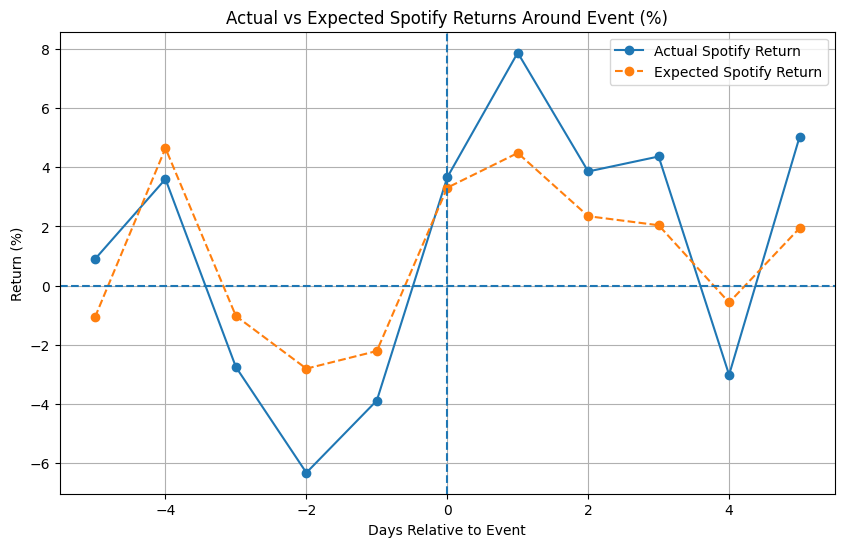

In [27]:
# Plot actual vs expected returns based on value weighted market model
df_event['spotify_return_pct'] = df_event['spotify_return'] * 100
df_event['expected_spotify_return_pct'] = df_event['expected_spotify_return'] * 100

plt.figure(figsize=(10,6))

plt.plot(df_event['relative_day'], df_event['spotify_return_pct'], marker='o', label='Actual Spotify Return')
plt.plot(df_event['relative_day'], df_event['expected_spotify_return_pct'], marker='o', linestyle='--', label='Expected Spotify Return')

plt.axvline(x=0, linestyle='--')
plt.axhline(y=0, linestyle='--')

plt.title('Actual vs Expected Spotify Returns Around Event (%)')
plt.xlabel('Days Relative to Event')
plt.ylabel('Return (%)')
plt.legend()
plt.grid(True)

plt.show()

After the event, Spotify’s actual returns consistently exceed expected returns, indicating a positive market reaction relative to broader market movements.

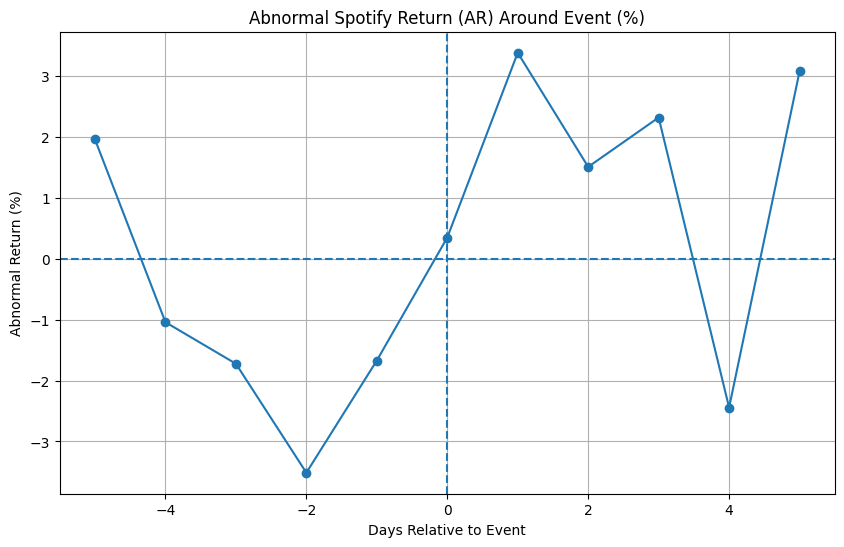

In [28]:
# Plot abnormal returns based on value weighted market model

df_event['abnormal_spotify_return_pct'] = df_event['abnormal_spotify_return'] * 100

plt.figure(figsize=(10,6))

plt.plot(df_event['relative_day'], df_event['abnormal_spotify_return_pct'], marker='o')

plt.axvline(x=0, linestyle='--')
plt.axhline(y=0, linestyle='--')

plt.title('Abnormal Spotify Return (AR) Around Event (%)')
plt.xlabel('Days Relative to Event')
plt.ylabel('Abnormal Return (%)')
plt.grid(True)

plt.show()

Abnormal returns shift from mostly negative before the event to predominantly positive afterward, suggesting the event generated short-term excess returns.

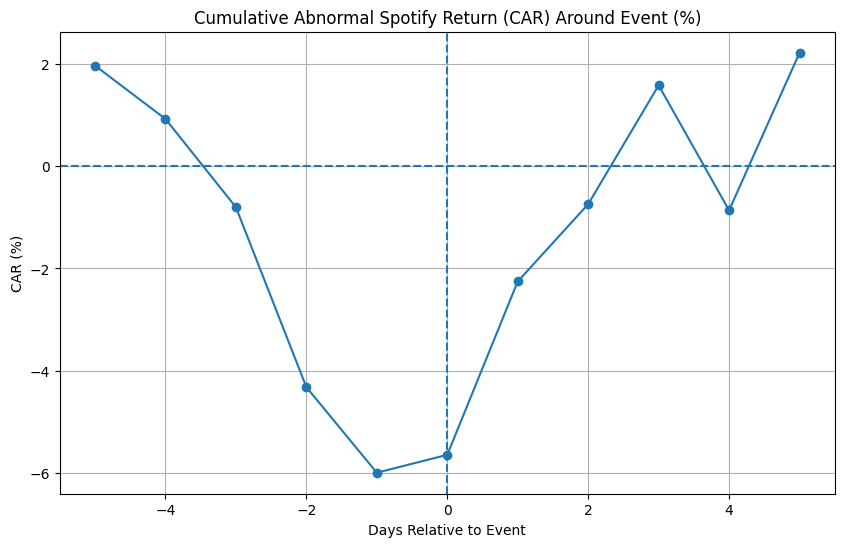

In [29]:
# Plot cumulative abnormal returns based on value weighted market model

df_event['CASR_pct'] = df_event['CASR'] * 100

plt.figure(figsize=(10,6))

plt.plot(df_event['relative_day'], df_event['CASR_pct'], marker='o')

plt.axvline(x=0, linestyle='--')
plt.axhline(y=0, linestyle='--')

plt.title('Cumulative Abnormal Spotify Return (CAR) Around Event (%)')
plt.xlabel('Days Relative to Event')
plt.ylabel('CAR (%)')
plt.grid(True)

plt.show()

Although CAR declines prior to the event, it reverses sharply afterward and ends positive, indicating an overall net gain associated with the event.

## 7. Value-weighted significance test

Test whether the cumulative abnormal return is statistically different from zero.

In [30]:
## Significance Test for CAR — Value-Weighted Market Model ##

# CAR for value-weighted model
car_vw = df_event['abnormal_spotify_return'].sum()
L = len(df_event)  # length of event window = 11

# Print the CAR value for verification
print(f"CAR (sum of abnormal returns): {car_vw:.6f}")
print()

# Unbiased estimate of residual std dev from the value-weighted estimation window
# ddof=2 because lm_vw estimated 2 parameters (alpha and beta)
sigma_ar_vw = lm_vw.resid.std(ddof=2)

# Standard Error of the CAR = sigma * sqrt(L)
se_car_vw = sigma_ar_vw * np.sqrt(L)

# t-statistic = CAR / SE(CAR)
t_stat_vw = car_vw / se_car_vw

# Degrees of freedom from the value-weighted estimation model (N - 2)
df_t_vw = lm_vw.df_resid

# Two-tailed p-value
p_value_vw = 2 * (1 - t.cdf(abs(t_stat_vw), df_t_vw))

print("=== Value-Weighted Market Model (vs S&P 500 value-weighted return) ===")
print(f"Cumulative Abnormal Return (CAR): {car_vw:.6f}  ({car_vw*100:.4f}%)")
print(f"Standard Error of CAR:            {se_car_vw:.6f}")
print(f"t-statistic:                      {t_stat_vw:.4f}")
print(f"Degrees of freedom:               {int(df_t_vw)}")
print(f"p-value:                          {p_value_vw:.4f}")

if p_value_vw < 0.05:
    print("\nConclusion: The CAR is statistically significant at the 5% level.")
else:
    print("\nConclusion: The CAR is NOT statistically significant at the 5% level.")

CAR (sum of abnormal returns): 0.022121

=== Value-Weighted Market Model (vs S&P 500 value-weighted return) ===
Cumulative Abnormal Return (CAR): 0.022121  (2.2121%)
Standard Error of CAR:            0.087982
t-statistic:                      0.2514
Degrees of freedom:               229
p-value:                          0.8017

Conclusion: The CAR is NOT statistically significant at the 5% level.


The value-weighted model CAR is positive, but not statistically significant.

## 8. S&P benchmark model

Re-estimate expected returns using the S&P 500 return as the benchmark.

The S&P 500 model is used as a robustness check to test whether the result is sensitive to benchmark choice.

In [31]:
# ========================
# S&P benchmark model
# Reuse the existing df from the earlier pipeline
# ========================


# Work off a clean copy so the main df is not overwritten accidentally
df_sp_model = df.copy()
df_sp_model['Date'] = pd.to_datetime(df_sp_model['Date'])
df_sp_model = df_sp_model.sort_values('Date').reset_index(drop=True)

# Define estimation and event dataframes from df_sp_model
est_data = df_sp_model[df_sp_model['Estimation_window'] == 1].copy()
event_data = df_sp_model[df_sp_model['event_window'] == 1].copy()


# Fit S&P market model ---
model_sp = smf.ols('spotify_return ~ sp_ret', data=est_data).fit()

print("=== Regression Statistics (Estimation Window) ===")
print(f"Alpha (Intercept): {model_sp.params['Intercept']:.6f}")
print(f"Beta (vs S&P 500): {model_sp.params['sp_ret']:.6f}")
print(f"R-squared: {model_sp.rsquared:.4f}")
print()

=== Regression Statistics (Estimation Window) ===
Alpha (Intercept): -0.002730
Beta (vs S&P 500): 1.677247
R-squared: 0.2093



## 9. S&P benchmark results

Calculate abnormal returns and CAR using the S&P model.

Plot actual vs expected returns, abnormal returns, and CAR for the S&P benchmark model.

In [32]:
# S&P event-window results
event_data = df_sp_model[df_sp_model['event_window'] == 1].copy()
event_data = event_data.sort_values('Date').reset_index(drop=True)

event_data['expected_ret_sp'] = model_sp.predict(event_data[['sp_ret']])
event_data['abnormal_ret_sp'] = event_data['spotify_return'] - event_data['expected_ret_sp']
event_data['CAR_sp'] = event_data['abnormal_ret_sp'].cumsum()

# Force event window indexing to match [-5, +5]
event_data['relative_day'] = np.arange(-5, 6)

results_sp = event_data[
    ['relative_day', 'Date', 'spotify_return', 'sp_ret', 'expected_ret_sp', 'abnormal_ret_sp', 'CAR_sp']
].copy()

print("=== Event Study Results: S&P Benchmark Model ===")
print(f"CAR [-5, +5]: {results_sp['abnormal_ret_sp'].sum() * 100:.4f}%")
display(results_sp.round(6))

=== Event Study Results: S&P Benchmark Model ===
CAR [-5, +5]: 4.1504%


,relative_day,Date,spotify_return,sp_ret,expected_ret_sp,abnormal_ret_sp,CAR_sp
0,-5,2022-03-08,0.008965,-0.007234,-0.014863,0.023828,0.023828
1,-4,2022-03-09,0.035996,0.025698,0.040372,-0.004376,0.019452
2,-3,2022-03-10,-0.027489,-0.004292,-0.009928,-0.017560,0.001891
3,-2,2022-03-11,-0.063164,-0.012962,-0.024470,-0.038695,-0.036803
4,-1,2022-03-14,-0.038780,-0.007421,-0.015177,-0.023604,-0.060407
5,0,2022-03-15,0.036578,0.021408,0.033177,0.003401,-0.057006
6,1,2022-03-16,0.078650,0.022384,0.034813,0.043837,-0.013169
7,2,2022-03-17,0.038554,0.012348,0.017980,0.020573,0.007404
8,3,2022-03-18,0.043610,0.011662,0.016831,0.026779,0.034183
9,4,2022-03-21,-0.030115,-0.000435,-0.003459,-0.026656,0.007528


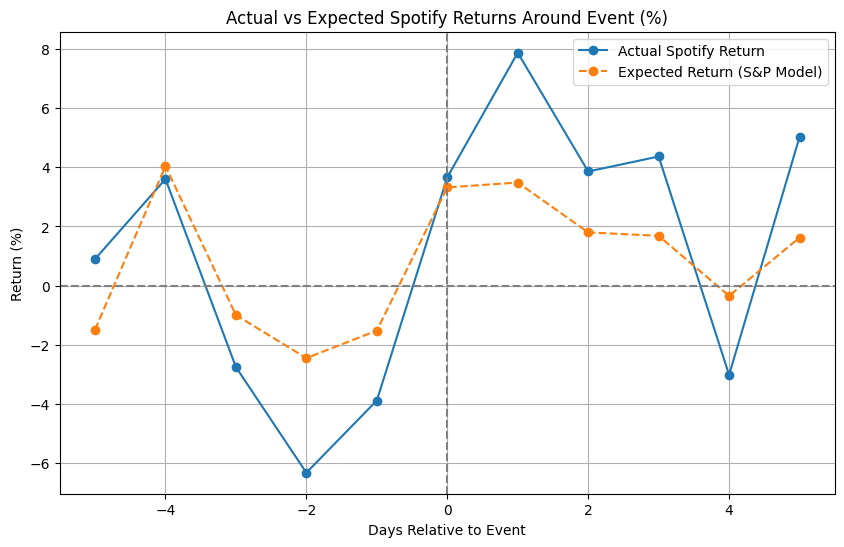

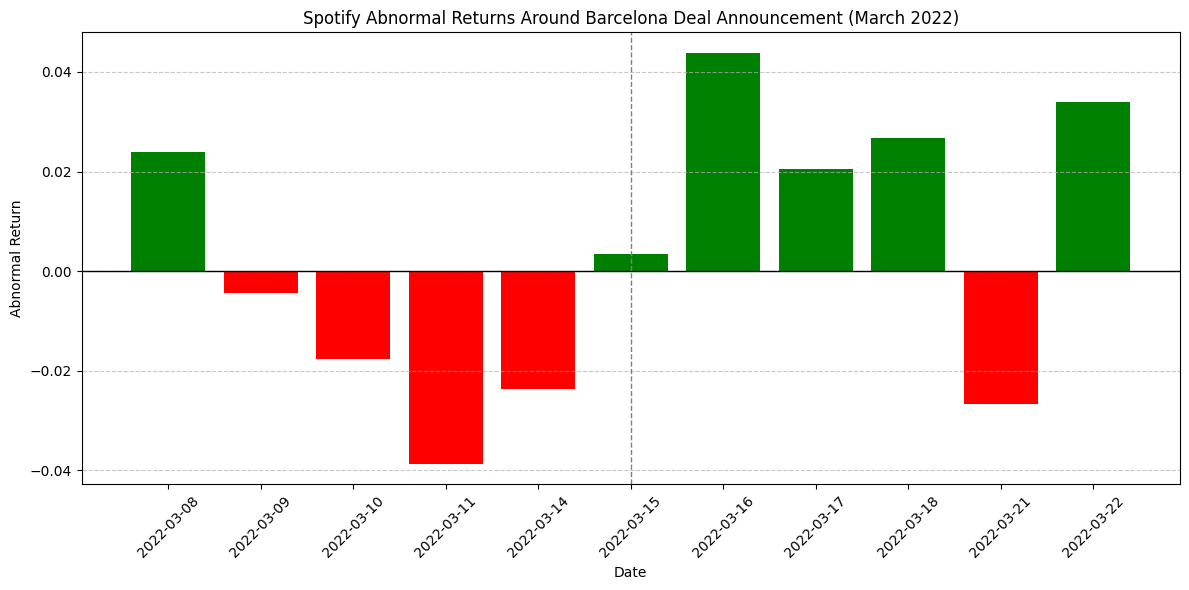

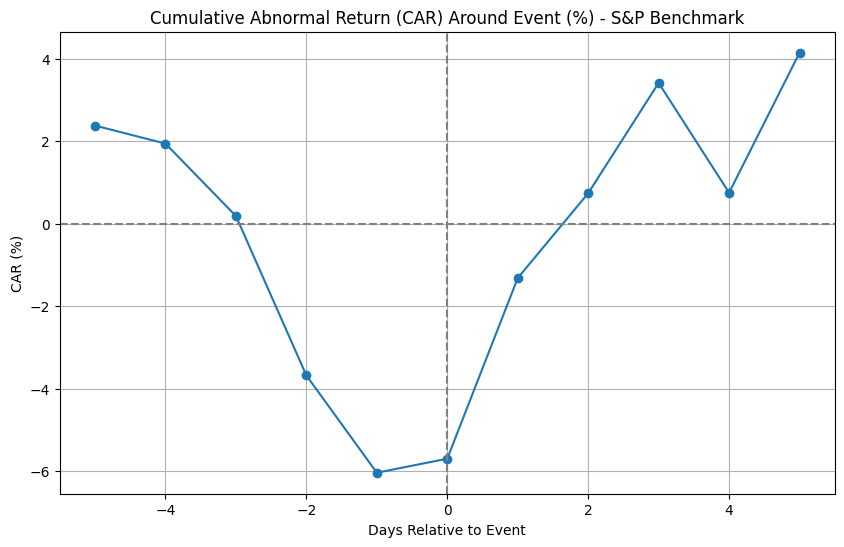

In [33]:
# Plot actual vs expected returns based on S&P 500 market model
plt.figure(figsize=(10, 6))
plt.plot(results_sp['relative_day'], results_sp['spotify_return'] * 100, marker='o', label='Actual Spotify Return')
plt.plot(results_sp['relative_day'], results_sp['expected_ret_sp'] * 100, marker='o', linestyle='--', label='Expected Return (S&P Model)')
plt.axvline(x=0, linestyle='--', color='gray')
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('Actual vs Expected Spotify Returns Around Event (%)')
plt.xlabel('Days Relative to Event')
plt.ylabel('Return (%)')
plt.legend()
plt.grid(True)
plt.show()

# Plot abnormal returns based on S&P 500 market model
plt.figure(figsize=(12, 6))

colors = ['red' if x < 0 else 'green' for x in event_data['abnormal_ret_sp']]

# Assign event_date from event_date_ref that was previously defined
event_date = event_date_ref

plt.bar(
    event_data['Date'].dt.strftime('%Y-%m-%d'),
    event_data['abnormal_ret_sp'],
    color=colors
)

plt.axhline(0, color='black', linewidth=1)
plt.axvline(
    x=list(event_data['Date'].dt.strftime('%Y-%m-%d')).index(event_date.strftime('%Y-%m-%d'))
    if event_date in set(event_data['Date']) else 5,
    color='gray',
    linestyle='--',
    linewidth=1
)

plt.title('Spotify Abnormal Returns Around Barcelona Deal Announcement (March 2022)')
plt.ylabel('Abnormal Return')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot cumulative abnormal returns based on S&P 500 market model
plt.figure(figsize=(10, 6))
plt.plot(results_sp['relative_day'], results_sp['CAR_sp'] * 100, marker='o')
plt.axvline(x=0, linestyle='--', color='gray')
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('Cumulative Abnormal Return (CAR) Around Event (%) - S&P Benchmark')
plt.xlabel('Days Relative to Event')
plt.ylabel('CAR (%)')
plt.grid(True)
plt.show()

The high beta highlights Spotify’s volatility, but the solid positive CAR demonstrates that the announcement was perceived as a net positive for shareholder value during the immediate period.

## 10. S&P significance test

Test whether the S&P benchmark CAR is statistically significant.

The S&P model also shows a positive CAR, but it is not statistically significant.

In [34]:
## Significance Test for Cumulative Abnormal Return (CAR) ##

# CAR is available from previous calculation
car = event_data['abnormal_ret_sp'].sum()
L = len(event_data)  # length of event window

# Unbiased estimate of residual standard deviation from estimation window
# ddof=2 because the market model estimated 2 parameters (alpha and beta)
sigma_ar = model_sp.resid.std(ddof=2)

# Standard Error of the CAR = sigma * sqrt(L)
se_car = sigma_ar * np.sqrt(L)

# t-statistic = CAR / SE(CAR)
t_stat = car / se_car

# Degrees of freedom from the estimation model (N - 2 parameters)
df_t = model_sp.df_resid

# Two-tailed p-value
p_value = 2 * (1 - t.cdf(abs(t_stat), df_t))

print(f"Cumulative Abnormal Return (CAR): {car:.6f}")
print(f"Standard Error of CAR: {se_car:.6f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"Degrees of freedom: {int(df_t)}")
print(f"p-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nConclusion: The CAR is statistically significant at the 5% level.")
else:
    print("\nConclusion: The CAR is NOT statistically significant at the 5% level.")

Cumulative Abnormal Return (CAR): 0.041504
Standard Error of CAR: 0.091631
t-statistic: 0.4530
Degrees of freedom: 229
p-value: 0.6510

Conclusion: The CAR is NOT statistically significant at the 5% level.


## 11. Interpretation

Both benchmark models indicate a positive short-term reaction to the March 15, 2022 announcement.

The value-weighted model reports a CAR of 2.2121% with a p-value of 0.8017, while the S&P benchmark model reports a CAR of 4.1504% with a p-value of 0.6510, so both results are positive but statistically insignificant at the 5% level.

